In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
analysis_df = pd.read_csv(
    "clean_online_retail.csv",
    parse_dates=["invoicedate"]
)

analysis_df.head()

C:\Users\Urvi Patel\AppData\Local\Temp\ipykernel_17852\2899044692.py:1: DtypeWarning: Columns (0: invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  analysis_df = pd.read_csv(


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,is_return,revenue,year,month,month_name,day,day_name,hour,quarter,week
0,NaN,NaN,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,False,83.4,2009,12,December,1,Tuesday,7,4,49
1,NaN,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
2,NaN,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
3,NaN,NaN,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,False,100.8,2009,12,December,1,Tuesday,7,4,49
4,NaN,NaN,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,False,30.0,2009,12,December,1,Tuesday,7,4,49


In [3]:
print(f"Rows: {analysis_df.shape[0]}")
print(f"Columns: {analysis_df.shape[1]}")

Rows: 1007913
Columns: 19


In [4]:
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 19 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1 non-null        str           
 1   stockcode     125868 non-null   str           
 2   description   1007913 non-null  str           
 3   quantity      1007913 non-null  int64         
 4   invoicedate   1007913 non-null  datetime64[us]
 5   price         1007913 non-null  float64       
 6   customer_id   779425 non-null   float64       
 7   country       1007913 non-null  str           
 8   is_cancelled  1007913 non-null  bool          
 9   is_return     1007913 non-null  bool          
 10  revenue       1007913 non-null  float64       
 11  year          1007913 non-null  int64         
 12  month         1007913 non-null  int64         
 13  month_name    1007913 non-null  str           
 14  day           1007913 non-null  int64         
 15  day_name 

In [5]:
analysis_df.describe().T

,count,mean,min,25%,50%,75%,max,std
quantity,1007913.0,11.117178,1.0,1.0,4.0,12.0,80995.0,128.470025
invoicedate,1007913,2011-01-04 10:34:18.759595,2009-12-01 07:45:00,2010-07-06 11:21:00,2010-12-09 15:29:00,2011-07-28 12:29:00,2011-12-09 12:50:00,NaN
price,1007913.0,4.074252,0.001,1.25,2.1,4.13,25111.09,50.430454
customer_id,779425.0,15320.360461,12346.0,13971.0,15247.0,16794.0,18287.0,1695.692775
revenue,1007913.0,20.315504,0.001,4.13,10.08,17.7,168469.6,205.715828
year,1007913.0,2010.436977,2009.0,2010.0,2010.0,2011.0,2011.0,0.576413
month,1007913.0,7.403545,1.0,4.0,8.0,11.0,12.0,3.499747
day,1007913.0,15.352177,1.0,8.0,15.0,23.0,31.0,8.639718
hour,1007913.0,13.020036,6.0,11.0,13.0,15.0,20.0,2.433195
quarter,1007913.0,2.78923,1.0,2.0,3.0,4.0,4.0,1.144557


In [6]:
missing = (
    analysis_df.isnull()
    .sum()
    .to_frame("Missing")
)

missing["Percent"] = (
    missing["Missing"] /
    len(analysis_df) * 100
)

missing

,Missing,Percent
invoice,1007912,99.999901
stockcode,882045,87.512017
description,0,0.000000
quantity,0,0.000000
invoicedate,0,0.000000
price,0,0.000000
customer_id,228488,22.669417
country,0,0.000000
is_cancelled,0,0.000000
is_return,0,0.000000


revenue analysis

In [7]:
total_revenue = analysis_df["revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £20,476,260.45


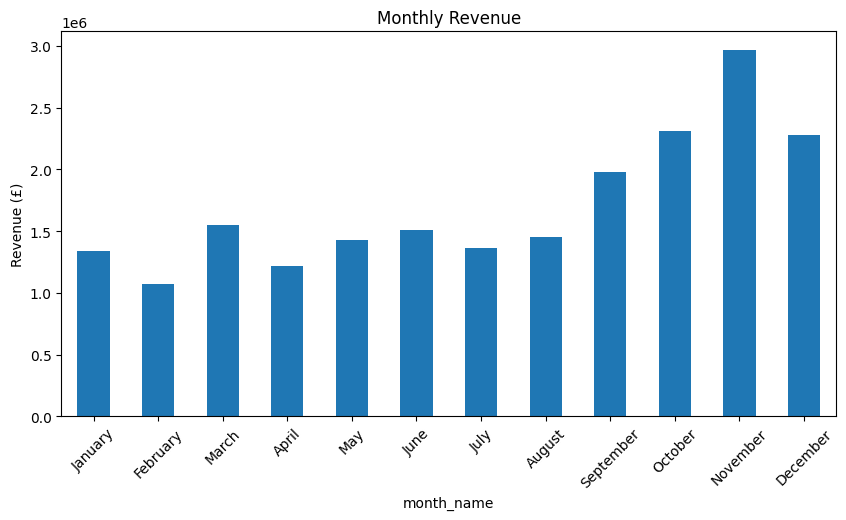

In [8]:
monthly_sales = (
    analysis_df
    .groupby("month_name")["revenue"]
    .sum()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ])
)

monthly_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Revenue (£)")
plt.title("Monthly Revenue")
plt.xticks(rotation=45)

plt.show()

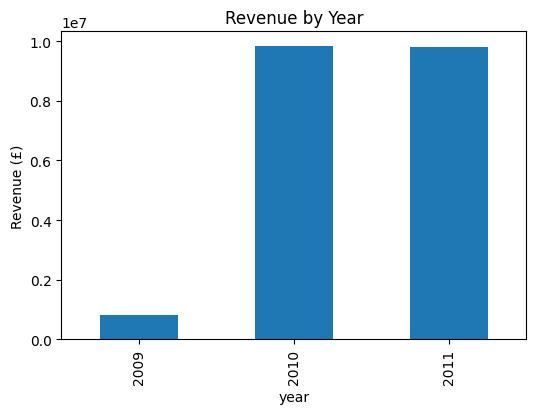

In [9]:
analysis_df.groupby("year")["revenue"].sum().plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Revenue (£)")
plt.title("Revenue by Year")

plt.show()

customer analysis

analysis_df["customer_id"].nunique()

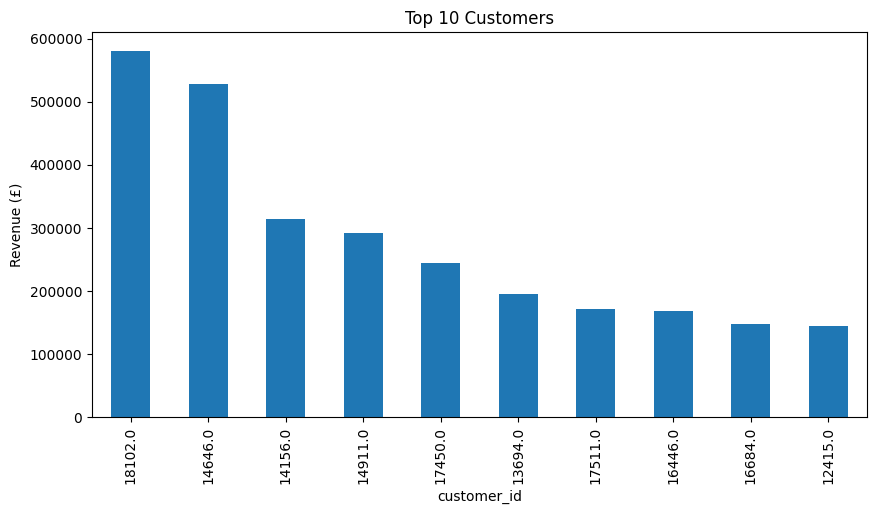

In [10]:
top_customers = (
    analysis_df.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Revenue (£)")
plt.title("Top 10 Customers")

plt.show()

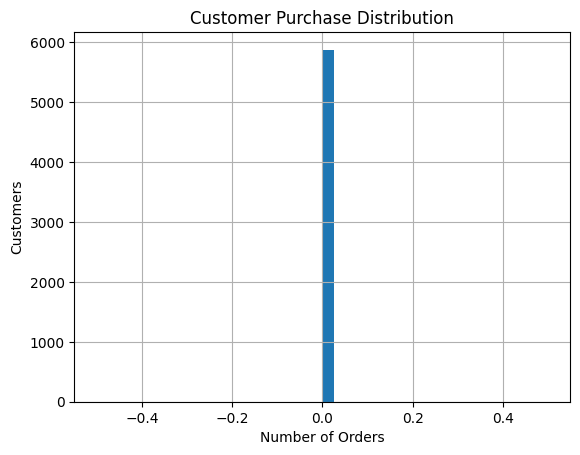

In [11]:
customer_orders = (
    analysis_df.groupby("customer_id")["invoice"]
    .nunique()
)

customer_orders.hist(bins=40)

plt.xlabel("Number of Orders")

plt.ylabel("Customers")

plt.title("Customer Purchase Distribution")

plt.show()

product

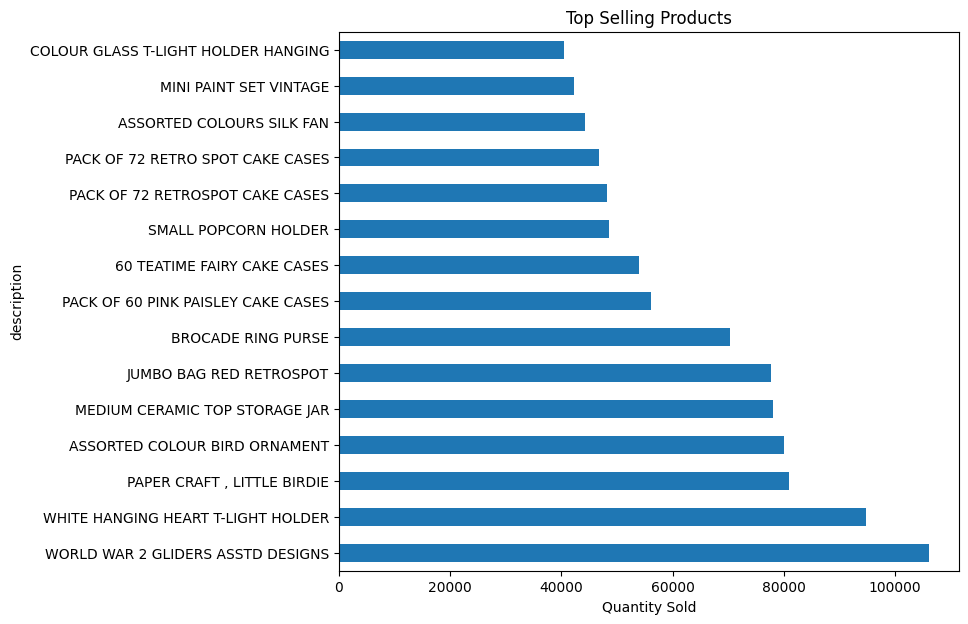

In [12]:
top_products = (
    analysis_df.groupby("description")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_products.plot(
    kind="barh",
    figsize=(8,7)
)

plt.title("Top Selling Products")

plt.xlabel("Quantity Sold")

plt.show()

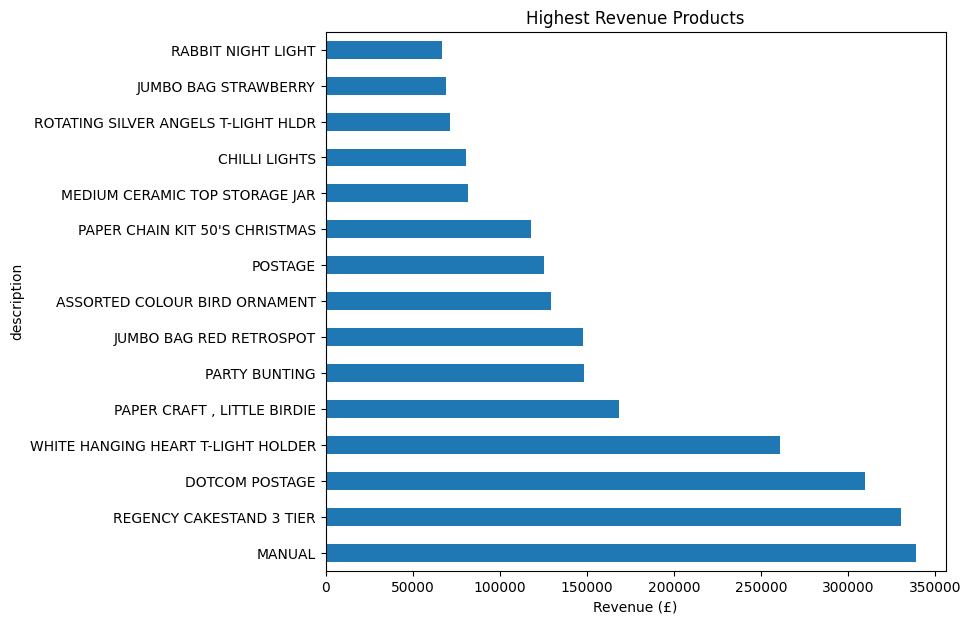

In [13]:
top_revenue_products = (
    analysis_df.groupby("description")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_revenue_products.plot(
    kind="barh",
    figsize=(8,7)
)

plt.title("Highest Revenue Products")

plt.xlabel("Revenue (£)")

plt.show()

revenue by country

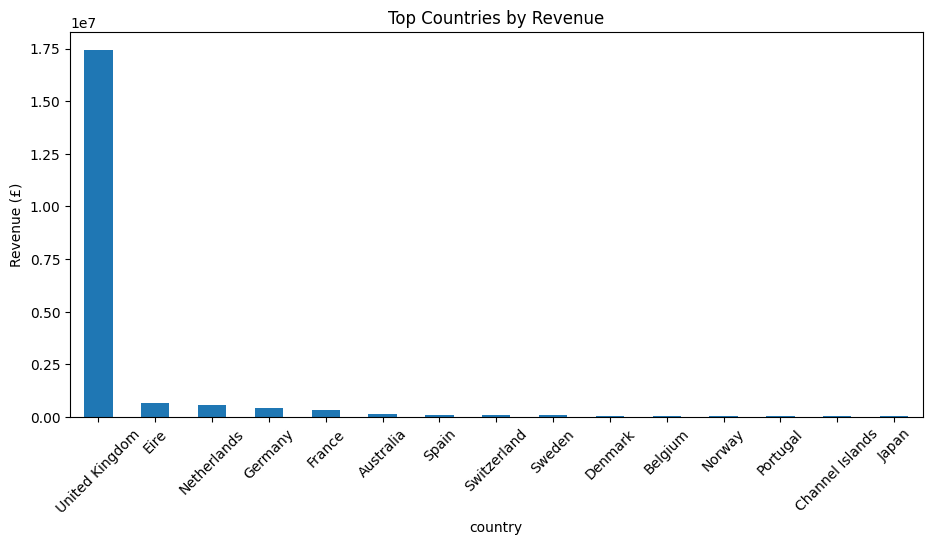

In [14]:
country_sales = (
    analysis_df.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

country_sales.plot(
    kind="bar",
    figsize=(11,5)
)

plt.ylabel("Revenue (£)")

plt.title("Top Countries by Revenue")

plt.xticks(rotation=45)

plt.show()

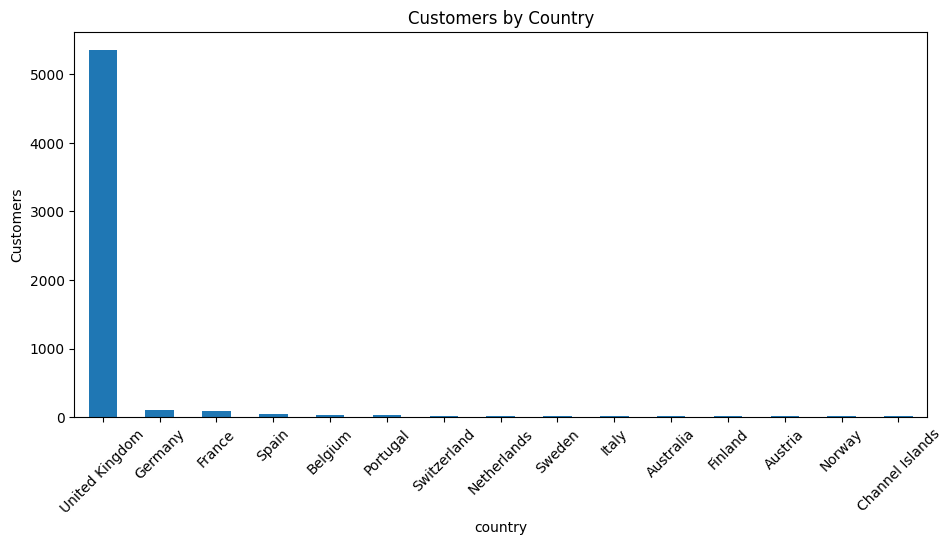

In [15]:
country_customers = (
    analysis_df.groupby("country")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

country_customers.plot(
    kind="bar",
    figsize=(11,5)
)

plt.ylabel("Customers")

plt.title("Customers by Country")

plt.xticks(rotation=45)

plt.show()

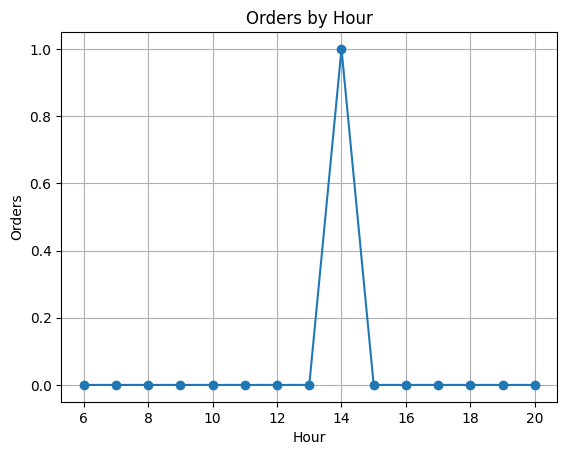

In [16]:
hourly = (
    analysis_df.groupby("hour")["invoice"]
    .nunique()
)

hourly.plot(marker="o")

plt.xlabel("Hour")

plt.ylabel("Orders")

plt.title("Orders by Hour")

plt.grid()

plt.show()

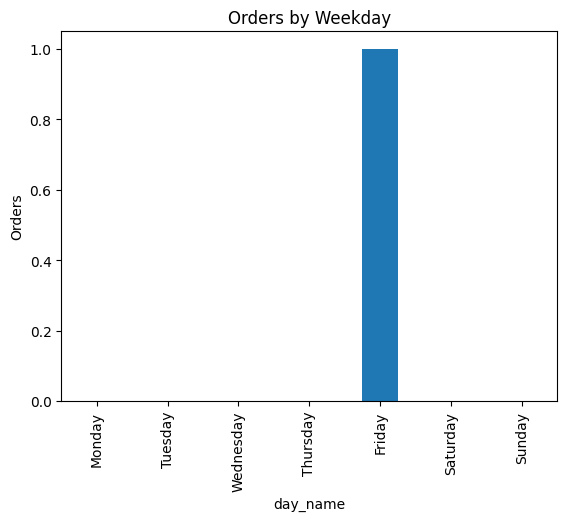

In [17]:
days = (
    analysis_df.groupby("day_name")["invoice"]
    .nunique()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

days.plot(kind="bar")

plt.ylabel("Orders")

plt.title("Orders by Weekday")

plt.show()

order analysis

In [18]:
invoice_revenue = (
    analysis_df.groupby("invoice")["revenue"]
    .sum()
)

aov = invoice_revenue.mean()

print(f"Average Order Value: £{aov:.2f}")

Average Order Value: £11062.06


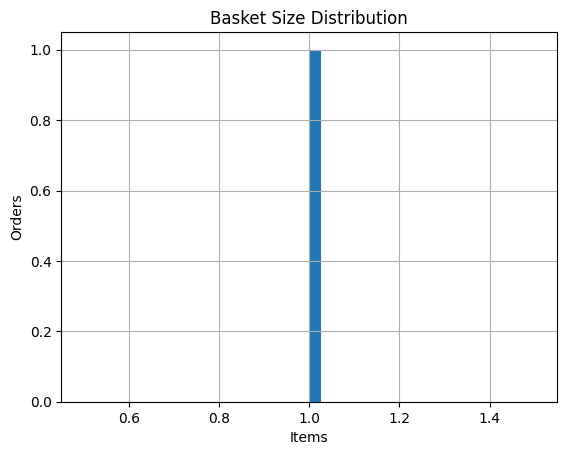

In [19]:
basket = (
    analysis_df.groupby("invoice")["quantity"]
    .sum()
)

basket.hist(bins=40)

plt.title("Basket Size Distribution")

plt.xlabel("Items")

plt.ylabel("Orders")

plt.show()

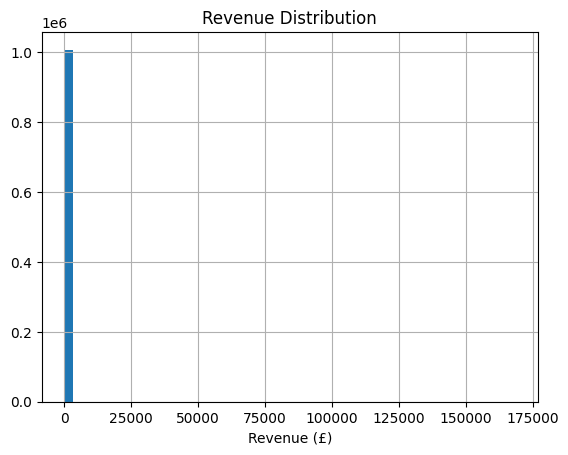

In [20]:
analysis_df["revenue"].hist(bins=50)

plt.title("Revenue Distribution")

plt.xlabel("Revenue (£)")

plt.show()

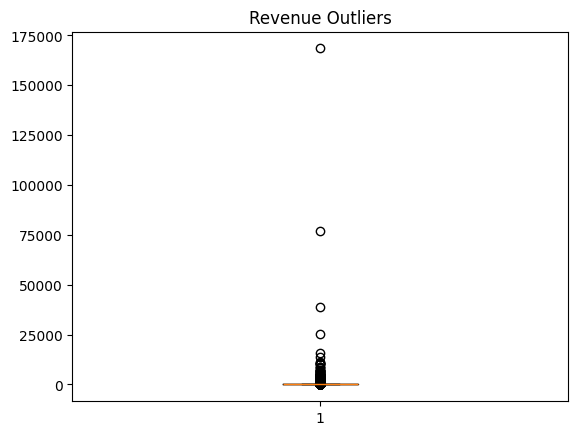

In [21]:
plt.boxplot(analysis_df["revenue"])

plt.title("Revenue Outliers")

plt.show()